# Practical 1. Where did the rat go?

A rat walked in a 1 m arena for 12 minutes. A camera filmed the rat at 50 frames per second. DeepLabCut found the position of the rat body in every frame.

You will find where the rat went and how fast it moved. Then you will track the rat yourself in one video frame.

How to work:

- Read the question.
- Write your code in the cell that shows `# YOUR CODE HERE`.
- Run the check cell below your code. No error means your answer is correct.
- Use the variable names that the question gives. The checks look for these names.
-There is no dumb question :)

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

FILES = {
    "motion.tsv": "69e7f1c36621cc1930afff4d",
    "channels.tsv": "69e7f1a20fe2aa5ba69231e8",
    "video.mp4": "69e7841f11f810cea4923087",
    "video.json": "69e783e31246f2add4fd86ed",
}
DATA = Path("data")
DATA.mkdir(exist_ok=True)
for name, osf_id in FILES.items():
    if not (DATA / name).exists():
        print("downloading", name)
        urlretrieve(f"https://osf.io/download/{osf_id}/", DATA / name)
print("data ready")

data ready


## Setup

This cell loads the body position as two arrays. It also loads the size of one pixel in cm and the pixel corners of the arena. Run it.

In [2]:
try:
    import av
except ImportError:                 # Google Colab has imageio but not PyAV
    %pip install -q "imageio[pyav]"

import json

import imageio.v3 as iio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import ndimage

fps = 50
table = pd.read_csv("data/motion.tsv", sep="\t")
body_x = table["body_x"].to_numpy()
body_y = table["body_y"].to_numpy()
channels = pd.read_csv("data/channels.tsv", sep="\t")
cm_per_px = channels["units/px"].iloc[0]
corners = json.load(open("data/video.json"))["PixelCoordinates"]
print(body_x.shape, cm_per_px, corners)

(36001,) 0.2766208215157828 {'LongName': 'Important pixel coordinates in the video recording.', 'top_left': [23, 14], 'top_right': [388, 16], 'bottom_left': [24, 377], 'bottom_right': [384, 374]}


## 1. How long is the recording?

Store the number of frames in `n_frames` and the duration in seconds in `duration_s`.

In [3]:
n_frames = len(body_x)
duration_s = n_frames / fps

In [4]:
assert n_frames == 36001, "use the length of the array"
assert np.isclose(duration_s, 720.02), "frames divided by frames per second"
print(n_frames, "frames,", duration_s, "s")

36001 frames, 720.02 s


## 2. Start and end

What is the distance, in cm, between the first position and the last position? Store the distance in `start_to_end`. `np.hypot(a, b)` computes the square root of a² + b².

In [5]:
start_to_end = np.hypot(body_x[-1] - body_x[0], body_y[-1] - body_y[0])

In [6]:
assert np.isclose(start_to_end, 62.07, atol=0.1), "distance between the first and the last frame"

## 3. Does the rat reach the walls?

The arena is about 100 cm wide. Store the smallest x value in `x_min`. Store the largest x value in `x_max`. Do the same for y: store the smallest value in `y_min` and the largest value in `y_max`.

In [7]:
x_min, x_max = body_x.min(), body_x.max()
y_min, y_max = body_y.min(), body_y.max()

In [8]:
assert x_max - x_min > 90 and y_max - y_min > 90, "the rat visits all of the arena"
assert x_min < 5 and y_min < 5

## 4. The path

Plot y against x with a thin line. Make the axes equal. Label both axes with units. Which corner does the rat like?

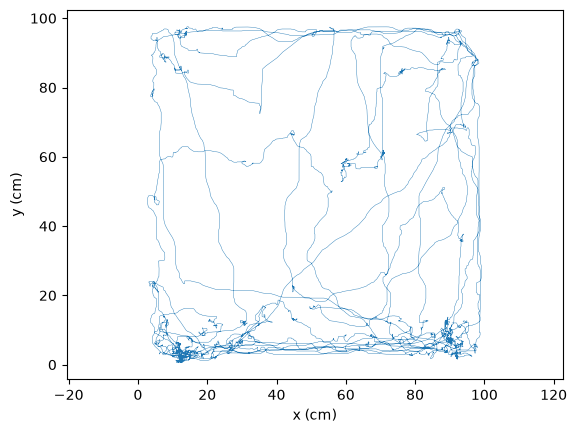

In [9]:
plt.plot(body_x, body_y, linewidth=0.3)
plt.xlabel("x (cm)")
plt.ylabel("y (cm)")
plt.axis("equal")
plt.show()

## 5. Speed

Compute the speed, in cm/s, between each pair of consecutive frames. Store the speed in `speed`. Steps: use `np.diff` on x and on y, use `np.hypot`, then multiply by `fps`.

In [10]:
dx = np.diff(body_x)
dy = np.diff(body_y)
speed = np.hypot(dx, dy) * fps

In [11]:
assert speed.shape == (36000,), "one speed per pair of frames"
assert np.isclose(np.median(speed), 1.205, atol=0.01), "did you multiply by fps?"
assert np.isclose(speed.max(), 120.75, atol=0.1)

## 6. A time axis

Make an array `time_s` with the time, in seconds, of each value in `speed`. Plot `speed` against `time_s` for the first 200 s.

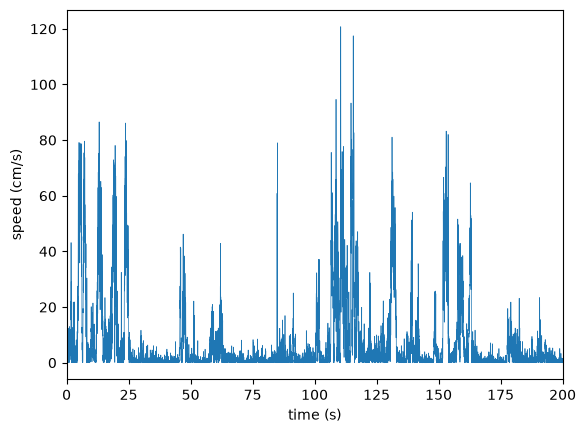

In [12]:
time_s = np.arange(len(speed)) / fps
plt.plot(time_s, speed, linewidth=0.5)
plt.xlim(0, 200)
plt.xlabel("time (s)")
plt.ylabel("speed (cm/s)")
plt.show()

In [13]:
assert time_s.shape == speed.shape, "one time per speed value"
assert np.isclose(time_s[-1], 719.98), "the first speed value is at time 0, as in the lecture"

## 7. Smooth it

The speed from one frame to the next is noisy. Average the speed over 1 s (50 frames) to get `speed_smooth`: `speed_smooth = np.convolve(speed, np.ones(fps) / fps, mode='same')`. Plot `speed` and `speed_smooth` on the same axes for the first 60 s.

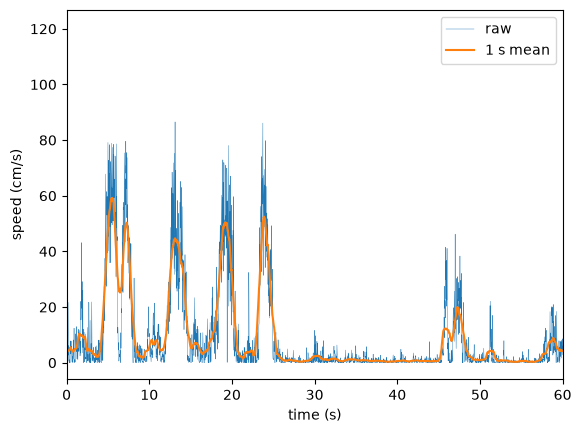

In [14]:
speed_smooth = np.convolve(speed, np.ones(fps) / fps, mode="same")
plt.plot(time_s, speed, linewidth=0.3, label="raw")
plt.plot(time_s, speed_smooth, label="1 s mean")
plt.xlim(0, 60)
plt.xlabel("time (s)")
plt.ylabel("speed (cm/s)")
plt.legend()
plt.show()

In [15]:
assert speed_smooth.shape == speed.shape
assert np.isclose(np.median(speed_smooth), 2.222, atol=0.01)
assert speed_smooth.max() < speed.max(), "smoothing lowers the peaks"

## 8. When does the rat move?

The rat moves when `speed_smooth` is above 5 cm/s. Store this Boolean array in `moving`. Store the fraction of frames where the rat moves in `fraction_moving`.

In [16]:
moving = speed_smooth > 5
fraction_moving = moving.mean()

In [17]:
assert moving.dtype == bool, "a comparison gives a boolean array"
assert np.isclose(fraction_moving, 0.3046, atol=0.005), "the mean of a boolean array is a fraction"
print(f"moving {fraction_moving:.0%} of the time")

moving 30% of the time


## 9. Fast and slow

Compute the mean of `speed_smooth` while the rat moves, and store it in `mean_moving_speed`. Do the same while the rat does not move, and store it in `mean_still_speed`. Use `moving` to select the frames.

In [18]:
mean_moving_speed = speed_smooth[moving].mean()
mean_still_speed = speed_smooth[~moving].mean()

In [19]:
assert mean_moving_speed > 10, "select with speed_smooth[moving]"
assert mean_still_speed < 3, "~moving is the opposite"

## 10. Total distance

How many meters did the rat walk? Sum the distance between each pair of consecutive frames. Store the total distance, in meters, in `distance_m`.

In [20]:
distance_m = np.hypot(dx, dy).sum() / 100

In [21]:
assert np.isclose(distance_m, 39.09, atol=0.1), "sum the per-frame distances. 100 cm in a meter"

## 11. Where does the rat spend its time?

Make a 2-D histogram of the rat position with 20 × 20 bins: `counts, x_edges, y_edges = np.histogram2d(...)`. Show `counts.T` with `origin='lower'`. The sum of `counts` must equal `n_frames`, because every frame falls in one bin.

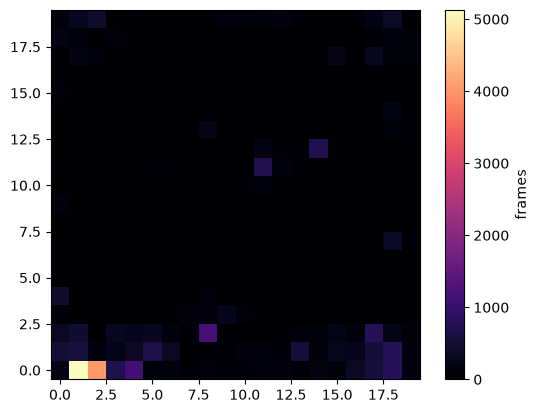

In [22]:
counts, x_edges, y_edges = np.histogram2d(body_x, body_y, bins=20)
plt.imshow(counts.T, origin="lower", cmap="magma")
plt.colorbar(label="frames")
plt.show()

In [23]:
assert counts.shape == (20, 20)
assert counts.sum() == n_frames, "every frame falls in one bin"
assert counts.max() == 5130

## 12. One video frame

Read frame 9000 into `frame` with `iio.imread(..., index=9000, plugin='pyav')`. Average the color axis of `frame` to get a gray image: `gray`. Crop `gray` to the arena with the corners: `arena`. Show `arena`.

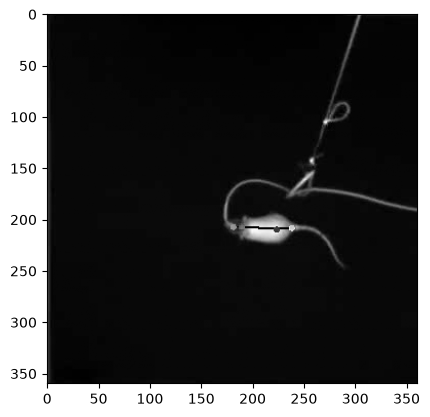

In [24]:
frame = iio.imread("data/video.mp4", index=9000, plugin="pyav")
gray = frame.mean(axis=2)
x0, y0 = corners["top_left"]
x1, y1 = corners["bottom_right"]
arena = gray[y0:y1, x0:x1]
plt.imshow(arena, cmap="gray")
plt.show()

In [25]:
assert frame.shape == (388, 410, 3), "rows, columns, colors"
assert gray.shape == (388, 410), "average over axis 2"
assert arena.shape == (360, 361), "rows are y, columns are x"

## 13. Find the rat

Blur `arena` with `ndimage.uniform_filter(arena, size=21)` to get `smooth`. Keep the pixels of `smooth` above the 99.5th percentile. Take the mean row and the mean column of these pixels, and convert both to cm with `cm_per_px`. Store the x position in `rat_x_cm` (from the columns) and the y position in `rat_y_cm` (from the rows). Compare `rat_x_cm` and `rat_y_cm` with `body_x[9000]` and `body_y[9000]`. Store the distance between the two positions in `error_cm`.

In [26]:
smooth = ndimage.uniform_filter(arena, size=21)
bright = smooth > np.percentile(smooth, 99.5)
rows, cols = np.where(bright)
rat_x_cm = cols.mean() * cm_per_px
rat_y_cm = rows.mean() * cm_per_px
error_cm = np.hypot(rat_x_cm - body_x[9000], rat_y_cm - body_y[9000])
print(rat_x_cm, rat_y_cm, error_cm)

59.022797472069904 58.150377958058584 2.7323252959680318


In [27]:
assert np.isclose(rat_x_cm, 59.0, atol=1.0), "columns give x"
assert np.isclose(rat_y_cm, 58.2, atol=1.0), "rows give y"
assert error_cm < 5, "more than 5 cm from DeepLabCut. Check the blur and the percentile"

## 14. Bonus: a function and a loop

Write a function `find_rat(index)` that returns `(x_cm, y_cm)` for any frame index. Use the steps of exercises 12 and 13 inside the function. Call `find_rat` for each index in `range(0, 36000, 3600)`. For each frame, compute the distance between the result of `find_rat` and the DeepLabCut point. Append each distance to the list `errors`. Store the median of `errors` in `median_error`.

In [28]:
def find_rat(index):
    frame = iio.imread("data/video.mp4", index=index, plugin="pyav")
    arena = frame.mean(axis=2)[y0:y1, x0:x1]
    smooth = ndimage.uniform_filter(arena, size=21)
    bright = smooth > np.percentile(smooth, 99.5)
    rows, cols = np.where(bright)
    return cols.mean() * cm_per_px, rows.mean() * cm_per_px

errors = []
for i in range(0, 36000, 3600):
    x_cm, y_cm = find_rat(i)
    errors.append(np.hypot(x_cm - body_x[i], y_cm - body_y[i]))
median_error = np.median(errors)
print(np.round(errors, 1), median_error)

[2.3 2.7 2.1 2.6 2.6 2.4 2.8 1.9 0.5 2.5] 2.4831126305301257


In [29]:
assert len(errors) == 10
assert median_error < 5, "the median error is above 5 cm. Check the crop and the blur"

## 15. Bonus: the empty arena

Stack the 10 gray arena images of the frames of exercise 14 into one 3-D array with `np.stack`. Store the result in `stack`. Take the median of `stack` over the frame axis. Store the result in `background`. Show `arena - background` for frame 9000. Where is the rat now?

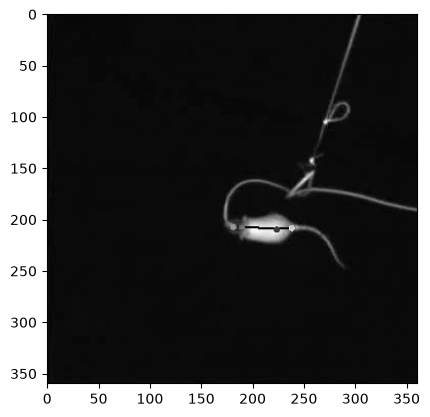

In [30]:
frames = [iio.imread("data/video.mp4", index=i, plugin="pyav").mean(axis=2)[y0:y1, x0:x1]
          for i in range(0, 36000, 3600)]
stack = np.stack(frames)
background = np.median(stack, axis=0)
plt.imshow(arena - background, cmap="gray")
plt.show()

In [31]:
assert stack.shape == (10, 360, 361), "frames first"
assert background.shape == (360, 361), "median over axis 0"
assert (arena - background).max() > 100, "the rat stands out from the background"

## Done

You loaded a table, made arrays, computed speed, selected data with Booleans, and tracked an animal in an image. In the next practical you will use the whole table and fit a line through a cloud of points.